In [1]:
import xgboost, dask, distributed, sys

print("xgboost:", xgboost.__version__)
print("dask:", dask.__version__)
print("distributed:", distributed.__version__)
print("python:", sys.version)

xgboost: 2.1.4
dask: 2024.12.1
distributed: 2024.12.1
python: 3.11.12 (main, Apr  9 2025, 08:55:55) [GCC 13.3.0]


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from newutils.data.datasets import load_train_subset, add_lags
from newutils.other.helpers import init_context
from oldutils.types import TimeRange
from oldutils.datasets import ARTIFACTS_FOLDER

init_context()

In [4]:
HORIZON_HISTORY = TimeRange.YEAR
HORIZON_FORECAST = TimeRange.WEEK

COL_GAUGE_ID = "gauge_id"
TARGETS = ["q_mm_day"]

In [5]:
df = load_train_subset(300)
df = df.repartition(partition_size="1MB")

In [6]:
lags = range(1, HORIZON_HISTORY + 1)
lags_columns = ["prcp", "t_max", "t_min", "t_mean", "lvl_sm"] # + ["q_mm_day"]
df = add_lags(df, lags_columns, lags)

In [7]:
targets = []
df = add_lags(df, targets, range(1, HORIZON_FORECAST + 1), targets)
targets.extend(TARGETS)

In [8]:
df = df.dropna()

In [9]:
from oldutils.datasets import STATIC_FEATURES
from oldutils.datasets import HydroStaticFeaturesFiles
import dask.dataframe as dd

hsff = (
    HydroStaticFeaturesFiles()
    .dataframe.collect()
    .to_pandas()[STATIC_FEATURES + ["gauge_id"]]
)
hsff = dd.from_pandas(hsff)
df = df.merge(hsff, how="left", on="gauge_id")
df = df.repartition(partition_size="1MB")
# df.head()

In [10]:
X = df.drop(columns=set(lags_columns + targets + ["date"]))
y = df[targets]
X_train, y_train = X, y

# Model

In [11]:
from dask.distributed import Client, LocalCluster, wait
import gc
import dask
import dask.array as da
import pandas as pd
import numpy as np
import dask.dataframe as dd
import xgboost.dask as dxgb
import warnings
from dask_cuda import LocalCUDACluster

cluster = LocalCluster(
    dashboard_address=":8789", asynchronous=False, n_workers=1, threads_per_worker=1
)
# cluster = LocalCUDACluster(
#     CUDA_VISIBLE_DEVICES="0",
#     n_workers=1,
#     threads_per_worker=1,
#     dashboard_address=":8789",
# )

In [ ]:
params = {
    'tree_method': 'hist',
    # 'device': 'cuda',
    "learning_rate": 0.1,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

EPS = 1e-6


def mape_obj(preds, dmat):
    y = dmat.get_label()
    grad = np.sign(preds - y) / (np.abs(y) + EPS)
    hess = EPS / (np.abs(y) + EPS) ** 2
    return grad, hess


def main():
    gc.collect()
    with Client(cluster) as client:
        print("Prepare datasets...")
        with warnings.catch_warnings(record=False) as caught_warnings:
            X_trainp = client.persist(X_train)
            wait(X_trainp)
            y_trainp = client.persist(y_train)
            wait(y_trainp)
        gc.collect()
        print("Create train set...")
        X_s, y_s = X_trainp, y_trainp
        dtrain = dxgb.DaskDMatrix(client, X_s, y_s)
        gc.collect()
        print("Train model...")
        results = dxgb.train(
            client,
            params,
            dtrain,
            num_boost_round=100,
            verbose_eval=10,
            evals=[(dtrain, "train")],
            obj=mape_obj,
        )
        gc.collect()
        print("Save model...")
        results["booster"].save_model(ARTIFACTS_FOLDER / "test_save.json")

        print("Training metrics and booster information:")
        print(results["history"])
        print(results["booster"])
    gc.collect()
    return results


result = main()
print(result)

Prepare datasets...


In [ ]:
X_test = X.get_partition(0).compute()

In [ ]:
import xgboost as xgb
import shap

booster = xgb.Booster()

booster.load_model(ARTIFACTS_FOLDER / "test_save.json")

# dtest = xgb.DMatrix(data=X_train)
# preds = booster.predict(dtest)

explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test)

/home/khuzin/.cache/pypoetry/virtualenvs/pro-1-experiments-jmzHMVzz-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


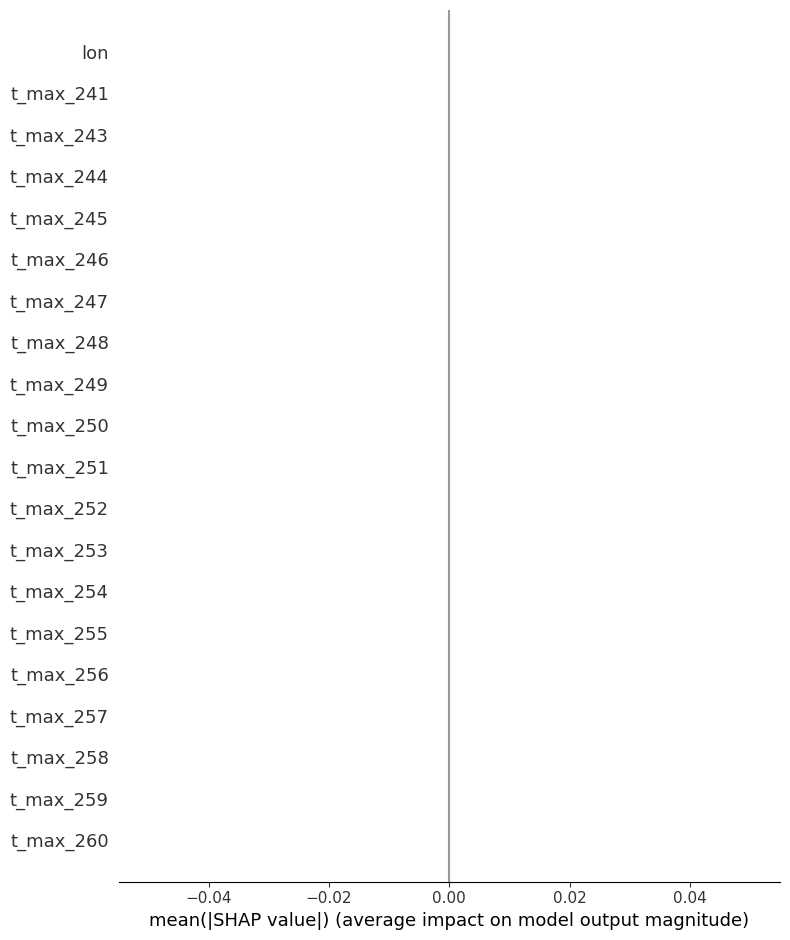

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

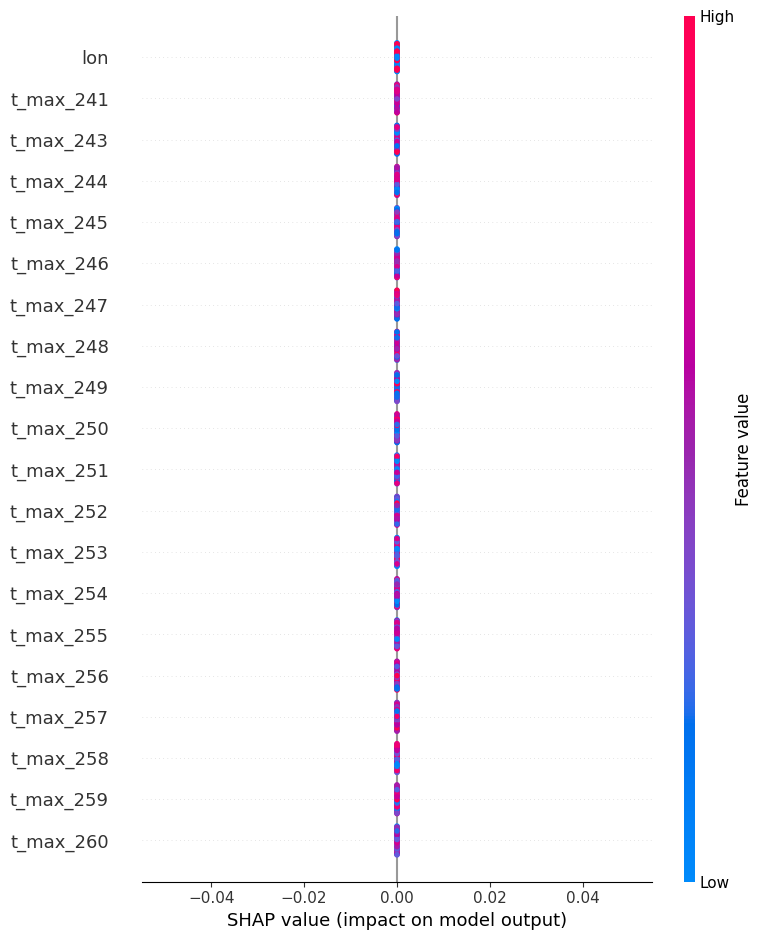

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
cluster.close()
gc.collect()

17610